# Study 256 -- Twitter-Mood
## For the quants: HAC lead-lag, the Granger-lag trap, permutation null, gross/net costs

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from twitter_mood import data, strategy as st

CACHE_PATH = data.INDEX_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    df_real = data.build_real_panel(fetch=False, cache_path=CACHE_PATH)
    sweep = st.leadlag_sweep(df_real, max_lag=5)
    print(f"Real panel loaded: {len(df_real)} business days "
          f"{df_real.index[0].date()} -> {df_real.index[-1].date()}")
else:
    df_real = sweep = None
    print("No real cache -- frozen headline numbers from R dict will be used")


Real panel loaded: 207 business days 2008-02-28 -> 2008-12-19


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_days': 207, 'window': '2008-02-28 -> 2008-12-19', 'fingerprint': 'a8dce11f0ac1', 'beta1': 0.00327, 't1': 0.9, 'r2_1': 0.0043, 'beta2': 0.00233, 't2': 0.63, 'beta3': 0.00192, 't3': 0.52, 'beta4': 0.00203, 't4': 0.56, 'beta5': 0.00244, 't5': 0.68, 'bonf_bar': 2.58, 'perm_p1': 0.35, 'perm_p2': 0.51, 'perm_p3': 0.57, 'hit_rate': 51.3, 'uncond_up': 50.8, 'edge_pts': 0.5, 'long_gross_ann': 3.9, 'long_gross_t': 0.17, 'long_net_ann': 3.2, 'long_net_t': 0.14, 'ls_gross_ann': 50.8, 'ls_gross_t': 1.32, 'ls_net_ann': 48.1, 'ls_net_t': 1.25, 'bh_ann': -43.1, 'bh_t': -1.18, 'pc_null_beta': -0.00054, 'pc_null_t': -0.57, 'pc_mid_beta': 0.00146, 'pc_mid_t': 1.57, 'pc_hi_beta': 0.00346, 'pc_hi_t': 3.71}


## Positive control: the engine recovers a planted lead-lag, reads ~0 on the null

In [3]:
for knob in [0.0, 0.002, 0.004]:
    dp, _ = data.synthetic_series(n_days=200, predictive=knob, seed=256)
    r = st.leadlag_regression(dp, lag=1)
    print(f"  predictive={knob:.3f}: beta={r['beta']:+.5f}  HAC t={r['tstat']:+.2f}")
print()
print(f"Frozen: null t={R['pc_null_t']:+.2f}, mid t={R['pc_mid_t']:+.2f}, planted t={R['pc_hi_t']:+.2f}")
print("-> The machinery is truthful: it finds a lead-lag when one exists.")


  predictive=0.000: beta=-0.00054  HAC t=-0.57
  predictive=0.002: beta=+0.00146  HAC t=+1.57
  predictive=0.004: beta=+0.00346  HAC t=+3.71

Frozen: null t=-0.57, mid t=+1.57, planted t=+3.71
-> The machinery is truthful: it finds a lead-lag when one exists.


## Lead-lag regression sweep (the Granger-lag multiple-comparisons trap)

In [4]:
if HAVE_REAL:
    print("=== ret_{t+lag} ~ a + b * Calm_t  (HAC t) ===")
    for _, row in sweep.iterrows():
        print(f"  lag {int(row['lag'])}: beta={row['beta']:+.5f}  HAC t={row['tstat']:+.2f}  R2={row['r2']:.4f}  n={int(row['n'])}")
    best = sweep.iloc[sweep['tstat'].abs().idxmax()]
    print(f"  Best |t| across 5 lags: lag {int(best['lag'])}  t={best['tstat']:+.2f}")
else:
    for L in range(1, 6):
        print(f"  lag {L}: beta={R[f'beta{L}']:+.5f}  HAC t={R[f't{L}']:+.2f}")
print(f"\nBonferroni bar for 5 lags at 5%: |t| ~ {R['bonf_bar']:.2f}. Nothing clears even the *uncorrected* bar.")


=== ret_{t+lag} ~ a + b * Calm_t  (HAC t) ===
  lag 1: beta=+0.00327  HAC t=+0.90  R2=0.0043  n=206
  lag 2: beta=+0.00233  HAC t=+0.63  R2=0.0022  n=205
  lag 3: beta=+0.00192  HAC t=+0.52  R2=0.0015  n=204
  lag 4: beta=+0.00203  HAC t=+0.56  R2=0.0016  n=203
  lag 5: beta=+0.00244  HAC t=+0.68  R2=0.0024  n=202
  Best |t| across 5 lags: lag 1  t=+0.90

Bonferroni bar for 5 lags at 5%: |t| ~ 2.58. Nothing clears even the *uncorrected* bar.


## Permutation null: where does the real slope land under time-shuffled mood?

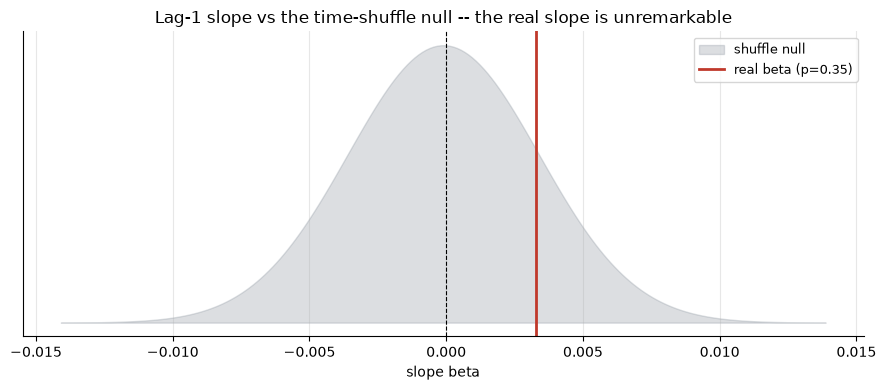

Real lag-1 beta=+0.00327  t=+0.90  permutation p=0.3505


In [5]:
if HAVE_REAL:
    sn = st.shuffle_null(df_real, lag=1, n_shuffles=2000, seed=256)
    betas_mean, betas_std = sn['perm_beta_mean'], sn['perm_beta_std']
    real_beta, perm_p = sn['real_beta'], sn['perm_p']
    # reconstruct an approximate null band for the plot
    xs = np.linspace(betas_mean - 4*betas_std, betas_mean + 4*betas_std, 200)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.fill_between(xs, np.exp(-0.5*((xs-betas_mean)/betas_std)**2), color=GREY, alpha=.3, label="shuffle null")
    ax.axvline(real_beta, color=RED, lw=2, label=f"real beta (p={perm_p:.2f})")
    ax.axvline(0, color="black", lw=0.8, ls="--")
    ax.set_title("Lag-1 slope vs the time-shuffle null -- the real slope is unremarkable")
    ax.set_xlabel("slope beta"); ax.set_yticks([]); ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()
    print(f"Real lag-1 beta={real_beta:+.5f}  t={sn['real_tstat']:+.2f}  permutation p={perm_p:.4f}")
else:
    print(f"Frozen permutation p-values: lag1={R['perm_p1']}, lag2={R['perm_p2']}, lag3={R['perm_p3']}")
    print("The real slope sits comfortably inside the null at every lag.")


## Directional hit-rate vs the unconditional up-rate (the base-rate trap)

In [6]:
if HAVE_REAL:
    hr = st.directional_hitrate(df_real, lookback=20)
    print(f"Calm-rule hit-rate : {hr['hit_rate']*100:.1f}%")
    print(f"Unconditional up   : {hr['uncond_up_rate']*100:.1f}%")
    print(f"Edge over baseline : {(hr['hit_rate']-hr['uncond_up_rate'])*100:+.1f} pts   (n={hr['n']})")
else:
    print(f"Frozen: hit={R['hit_rate']}%  uncond={R['uncond_up']}%  edge=+{R['edge_pts']} pts")
print("\nThe binary predictor inherits the market's upward drift -- it is not skill.")


Calm-rule hit-rate : 51.3%
Unconditional up   : 50.8%
Edge over baseline : +0.5 pts   (n=197)

The binary predictor inherits the market's upward drift -- it is not skill.


## Trading rule: gross/net, long-only vs long-short, with a 1-day execution lag

In [7]:
if HAVE_REAL:
    for short, label in [(False, "long/flat"), (True, "long/short")]:
        res = st.mood_strategy(df_real, lookback=20, allow_short=short, one_way_bps=5.0)
        sg, snet, sm = st.summarize(res['gross']), st.summarize(res['net']), st.summarize(res['mkt'])
        print(f"[{label}] gross {sg['mean']*252*100:+.1f}%/yr (t={sg['tstat']:+.2f}) | "
              f"net@5bps {snet['mean']*252*100:+.1f}%/yr (t={snet['tstat']:+.2f})")
    print(f"Buy & hold (window): {sm['mean']*252*100:+.1f}%/yr (t={sm['tstat']:+.2f})  <- the 2008 crash")
else:
    print(f"[long/flat ] gross {R['long_gross_ann']:+.1f}%/yr (t={R['long_gross_t']:+.2f}) | net {R['long_net_ann']:+.1f}%/yr (t={R['long_net_t']:+.2f})")
    print(f"[long/short] gross {R['ls_gross_ann']:+.1f}%/yr (t={R['ls_gross_t']:+.2f}) | net {R['ls_net_ann']:+.1f}%/yr (t={R['ls_net_t']:+.2f})")
    print(f"Buy & hold (window): {R['bh_ann']:+.1f}%/yr (t={R['bh_t']:+.2f})")
print("\nThe long-short 'edge' is a net-short-into-the-crash artefact; it does NOT clear t>=2.")
print("Shorts pay borrow (charged); costs are one-way bps x |dpos| on NAV.")


[long/flat] gross +3.9%/yr (t=+0.17) | net@5bps +3.2%/yr (t=+0.14)
[long/short] gross +50.8%/yr (t=+1.32) | net@5bps +48.1%/yr (t=+1.25)
Buy & hold (window): -43.1%/yr (t=-1.18)  <- the 2008 crash

The long-short 'edge' is a net-short-into-the-crash artefact; it does NOT clear t>=2.
Shorts pay borrow (charged); costs are one-way bps x |dpos| on NAV.


## The n=207 power problem

In [8]:
# With ~207 daily obs and a true daily R^2 of ~1%, what t-stat could we even hope for?
import numpy as np
n = R['n_days']
for true_r2 in [0.005, 0.01, 0.02]:
    # approx slope t = sqrt(R2/(1-R2) * (n-2))
    t_exp = np.sqrt(true_r2/(1-true_r2) * (n-2))
    print(f"  true daily R2={true_r2:.3f}: expected |t| ~ {t_exp:.2f}")
print(f"\nObserved lag-1 R2={R['r2_1']:.4f} -> expected |t|<1. The window is simply")
print("too short to detect a faint 1-3 day lead-lag, even if one truly existed.")


  true daily R2=0.005: expected |t| ~ 1.01
  true daily R2=0.010: expected |t| ~ 1.44
  true daily R2=0.020: expected |t| ~ 2.05

Observed lag-1 R2=0.0043 -> expected |t|<1. The window is simply
too short to detect a faint 1-3 day lead-lag, even if one truly existed.


## Verdict

In [9]:
print("=== Study 256 -- Twitter-Mood ===")
print()
print(f"Signal: NONE")
print(f"  Lag-1 lead-lag HAC t = +{R['t1']:.2f}; no lag in the 1-5 sweep clears t>=2")
print(f"  Permutation p = {R['perm_p1']} (lag 1); directional edge = +{R['edge_pts']} pts over base rate")
print(f"  n = {R['n_days']} business days -- underpowered; mood tape is a curated proxy")
print()
print(f"Tradability: MIRAGE")
print(f"  Long-only rule flat after costs (t={R['long_net_t']:.2f})")
print(f"  Long-short +{R['ls_net_ann']:.0f}%/yr is a 2008-crash net-short artefact (t={R['ls_net_t']:.2f}, < 2)")
print()
print("Honesty: curated-proxy mood tape (not the GPOMS feed); price-only S&P;")
print("  one-day execution lag; one-way costs x NAV; shorts pay borrow -- all applied.")
print()
print("Bottom line: None/Mirage -- the canonical 'social-media alpha' claim is a")
print("  mirage that the famous replication (Lachanski & Pav 2017) already buried.")


=== Study 256 -- Twitter-Mood ===

Signal: NONE
  Lag-1 lead-lag HAC t = +0.90; no lag in the 1-5 sweep clears t>=2
  Permutation p = 0.35 (lag 1); directional edge = +0.5 pts over base rate
  n = 207 business days -- underpowered; mood tape is a curated proxy

Tradability: MIRAGE
  Long-only rule flat after costs (t=0.14)
  Long-short +48%/yr is a 2008-crash net-short artefact (t=1.25, < 2)

Honesty: curated-proxy mood tape (not the GPOMS feed); price-only S&P;
  one-day execution lag; one-way costs x NAV; shorts pay borrow -- all applied.

Bottom line: None/Mirage -- the canonical 'social-media alpha' claim is a
  mirage that the famous replication (Lachanski & Pav 2017) already buried.
